# Model Training

End-to-end training pipeline for the cross-sell propensity model:
Load → Feature Engineering → Tune → Train → Evaluate → Save → Log to MLflow

## 1. Setup

In [ ]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()   # project root — all paths resolve from here
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

from src.data import load_config, load_raw, clean, split
from src.features import build_feature_matrix
from src.model import tune_hyperparameters, train_model, tune_threshold, evaluate, save_model

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 4)

cfg       = load_config(ROOT / "config.yaml")
TARGET    = cfg["data"]["target_col"]
DROP_COLS = ["id", TARGET]

print(f"Project root: {ROOT}")

## 2. Load & Engineer Features

In [ ]:
df = clean(load_raw(ROOT / cfg["paths"]["raw_dir"]))
train_df, test_df = split(
    df,
    test_size=cfg["data"]["test_size"],
    random_state=cfg["split"]["random_state"],
)

train_eng = build_feature_matrix(train_df)
test_eng  = build_feature_matrix(test_df)

X_train = train_eng.drop(columns=DROP_COLS)
y_train = train_eng[TARGET]
X_test  = test_eng.drop(columns=DROP_COLS)
y_test  = test_eng[TARGET]

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

## 3. Hyperparameter Tuning

In [3]:
best_params = tune_hyperparameters(
    X_train, y_train,
    n_trials=cfg["tuning"]["n_trials"],
    cv_folds=cfg["tuning"]["cv_folds"],
    random_state=cfg["split"]["random_state"],
)

print("\nBest hyperparameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]

Best CV PR-AUC: 0.3716

Best hyperparameters:
  n_estimators: 256
  max_depth: 7
  learning_rate: 0.02429932274939647
  subsample: 0.9989827331722597
  colsample_bytree: 0.8062858251086147
  min_child_weight: 5


## 4. Train Final Model

In [4]:
pipeline = train_model(
    X_train, y_train,
    best_params,
    random_state=cfg["split"]["random_state"],
)
print("Pipeline trained:", pipeline)

Pipeline trained: Pipeline(steps=[('freq_encoder',
                 FrequencyEncoder(cols=['Policy_Sales_Channel',
                                        'Region_Code'])),
                ('target_encoder',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('target_enc',
                                                  TargetEncoder(random_state=42,
                                                                target_type='binary'),
                                                  ['Policy_Sales_Channel',
                                                   'Region_Code'])],
                                   verbose_feature_names_out=False)),
                ('model',
                 XGBClassifier(base_score=None, b...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
            

## 5. Evaluate

In [5]:
probs     = pipeline.predict_proba(X_test)[:, 1]
threshold = tune_threshold(y_test, probs, beta=2.0)
result    = evaluate("XGBoost (tuned)", y_test, probs, threshold=threshold)

pd.DataFrame([result]).set_index("model")

,pr_auc,roc_auc,precision,recall,threshold
model,,,,,
XGBoost (tuned),0.3679,0.8576,0.2843,0.9287,0.4954


## 6. PR & ROC Curves

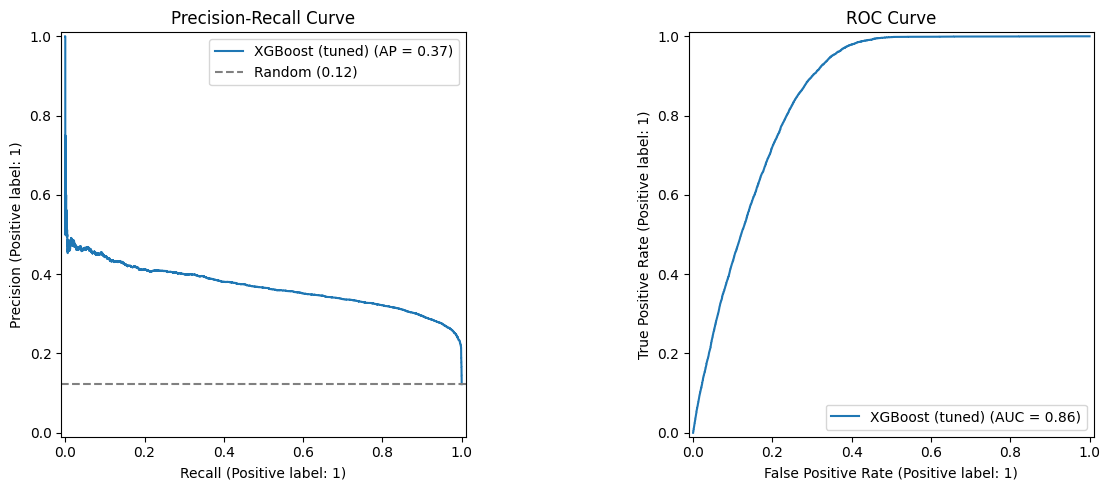

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

PrecisionRecallDisplay.from_predictions(y_test, probs, name="XGBoost (tuned)", ax=axes[0])
axes[0].axhline(y_test.mean(), color="grey", linestyle="--", label=f"Random ({y_test.mean():.2f})")
axes[0].set_title("Precision-Recall Curve")
axes[0].legend()

RocCurveDisplay.from_predictions(y_test, probs, name="XGBoost (tuned)", ax=axes[1])
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()

## 7. Save Model

In [ ]:
save_model(pipeline, threshold, path=ROOT / cfg["paths"]["model_file"])
print(f"Model saved to: {ROOT / cfg['paths']['model_file']}")

## 8. Log to MLflow

In [ ]:
mlflow.set_tracking_uri(str(ROOT / "mlruns"))
mlflow.set_experiment("cross-sell-propensity")

with mlflow.start_run(run_name="XGBoost (tuned)"):
    mlflow.set_tags({
        "stage":    "tuned",
        "features": "engineered + pipeline (freq + target encoding)",
        "dataset":  "health-insurance-cross-sell",
    })

    mlflow.log_params({
        "model_type": "XGBoost",
        **{k: round(v, 4) if isinstance(v, float) else v for k, v in best_params.items()},
    })

    mlflow.log_metrics({
        "pr_auc":    result["pr_auc"],
        "roc_auc":   result["roc_auc"],
        "precision": result["precision"],
        "recall":    result["recall"],
        "threshold": result["threshold"],
    })

    mlflow.sklearn.log_model(pipeline, artifact_path="model")

    print(f"✓ Logged run | PR-AUC: {result['pr_auc']} | ROC-AUC: {result['roc_auc']}")
    print(f"Runs saved to: {ROOT / 'mlruns'}")